# User Behavior Analysis (E-commerce)

## Project Overview

This project analyzes 100,000 user behavior records from an e-commerce platform, including user browsing, cart, and purchase activities.

The goal is to understand user behavior patterns, product performance, and customer value, and provide actionable business insights.

# 1. Data Cleaning
# 2. Exploratory Data Analysis
# 3. User Behavior Funnel Analysis
# 4. Brand Analysis
# 5. Price Analysis
# 6. RFM Analysis
# 7. Customer Segmentation
# 8. Business Insights
# 9. Conclusion

In [27]:
import pandas as pd

df = pd.read_csv(
    "../data/2019-Nov.csv",
    nrows=100000
)

df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [28]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


# 1. Data Cleaning

This section focuses on data preprocessing, including checking missing values, duplicate records, and data types.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     100000 non-null  object 
 1   event_type     100000 non-null  object 
 2   product_id     100000 non-null  int64  
 3   category_id    100000 non-null  int64  
 4   category_code  66160 non-null   object 
 5   brand          84224 non-null   object 
 6   price          100000 non-null  float64
 7   user_id        100000 non-null  int64  
 8   user_session   100000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


In [30]:
df.describe()

,product_id,category_id,price,user_id
count,1.000000e+05,1.000000e+05,100000.000000,1.000000e+05
mean,1.123577e+07,2.057926e+18,281.539756,5.354871e+08
std,1.219807e+07,1.965420e+16,342.414641,2.031755e+07
min,1.000978e+06,2.053014e+18,0.000000,2.752567e+08
25%,1.200954e+06,2.053014e+18,65.640000,5.159248e+08
50%,5.301584e+06,2.053014e+18,164.950000,5.315900e+08
75%,1.650001e+07,2.053014e+18,350.852500,5.549301e+08
max,6.050000e+07,2.180737e+18,2574.070000,5.663100e+08


In [31]:
# 查看每一列缺失值数量
df.isnull().sum()

event_time           0
event_type           0
product_id           0
category_id          0
category_code    33840
brand            15776
price                0
user_id              0
user_session         0
dtype: int64

In [32]:
# 查看行为类型
df["event_type"].value_counts()

event_type
view        97489
purchase     1422
cart         1089
Name: count, dtype: int64

In [33]:
# 查看价格统计
df["price"].describe()

count    100000.000000
mean        281.539756
std         342.414641
min           0.000000
25%          65.640000
50%         164.950000
75%         350.852500
max        2574.070000
Name: price, dtype: float64

In [34]:
(df["price"] == 0).sum()

np.int64(63)

In [35]:
# 转换时间格式
df["event_time"] = pd.to_datetime(df["event_time"])

In [36]:
# 提取小时
df["hour"] = df["event_time"].dt.hour

## 2.1 Price Distribution Analysis

We analyze the distribution of product prices to understand consumer market structure.

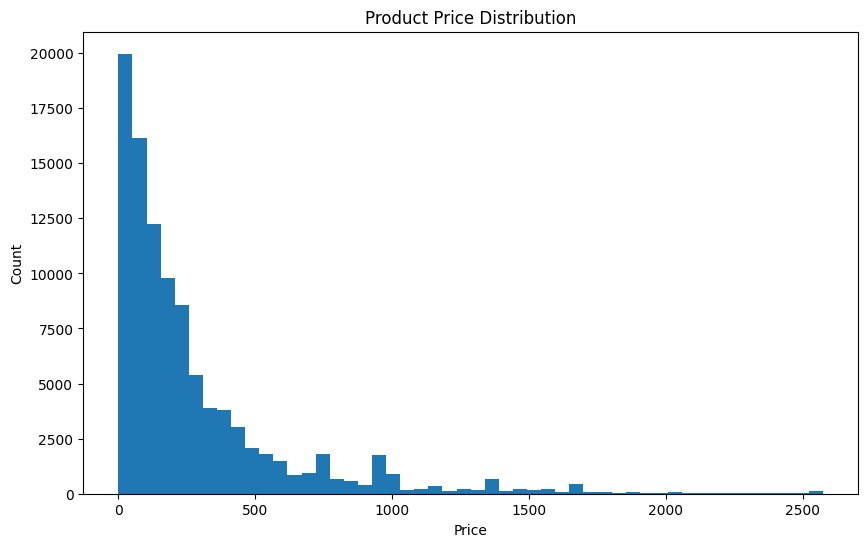

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["price"], bins=50)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

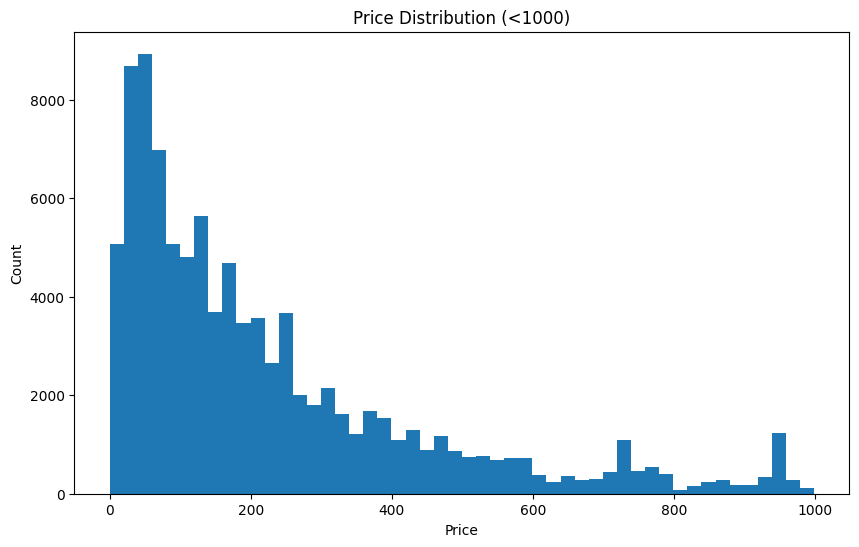

In [38]:
price = df[df["price"] < 1000]["price"]

plt.figure(figsize=(10,6))

plt.hist(price, bins=50)

plt.title("Price Distribution (<1000)")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [39]:
purchase = df[df["event_type"] == "purchase"]

purchase["price"].describe()

count    1422.000000
mean      282.438537
std       318.515618
min         3.840000
25%        72.522500
50%       172.230000
75%       357.540000
max      2011.630000
Name: price, dtype: float64

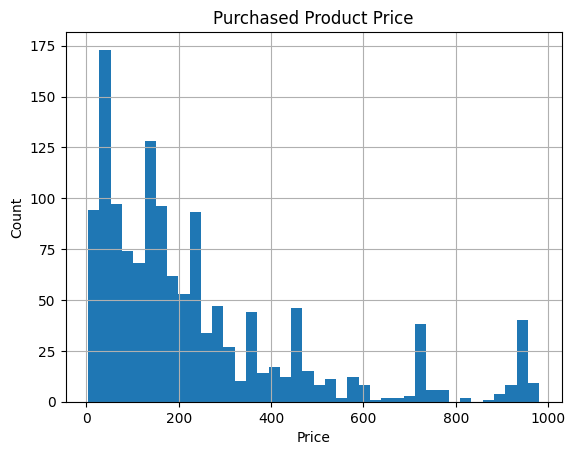

In [40]:
purchase[purchase["price"] < 1000]["price"].hist(bins=40)

plt.title("Purchased Product Price")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

### Insight

Most products are concentrated in the low-price range, showing a right-skewed distribution.

## 2.2 Brand Analysis

This section identifies the most popular brands based on user interactions.

In [41]:
df["brand"].value_counts().head(10)

brand
samsung     11748
apple        8566
xiaomi       7400
huawei       2228
lucente      1460
oppo         1256
sony         1186
cordiant     1169
bosch        1145
lg           1117
Name: count, dtype: int64

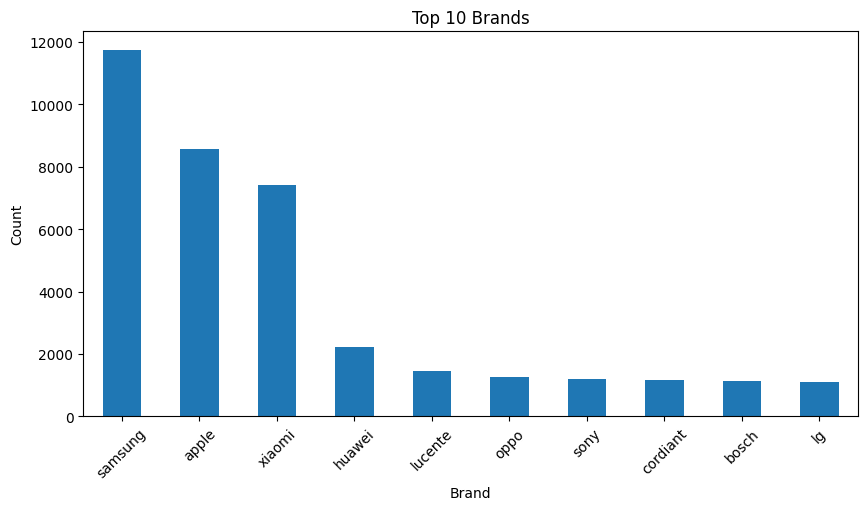

In [42]:
top_brand = df["brand"].value_counts().head(10)

top_brand.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Insight

Brands such as Samsung, Apple, and Xiaomi dominate user interactions, indicating strong market visibility.

In [43]:
df.groupby("event_type")["price"].mean()

event_type
cart        307.045464
purchase    282.438537
view        281.241735
Name: price, dtype: float64

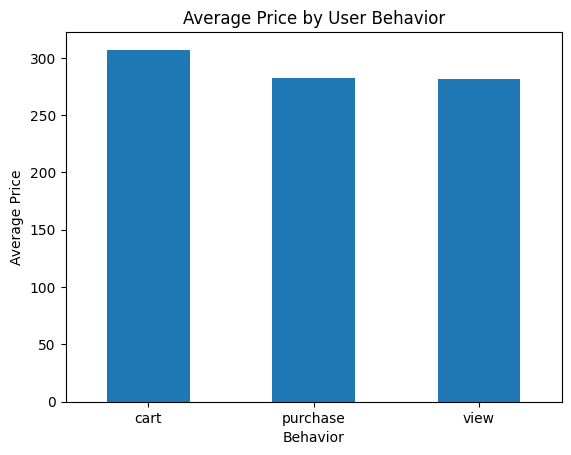

In [44]:
avg_price = df.groupby("event_type")["price"].mean()

avg_price.plot(kind="bar")

plt.title("Average Price by User Behavior")
plt.xlabel("Behavior")
plt.ylabel("Average Price")

plt.xticks(rotation=0)

plt.show()

## 2.3 Product Analysis

In [45]:
df["product_id"].value_counts().head(10)

product_id
1004856    1132
1004767     942
1005115     906
1004833     566
1004249     527
1005105     526
1004870     517
4804056     495
1005160     489
1002544     470
Name: count, dtype: int64

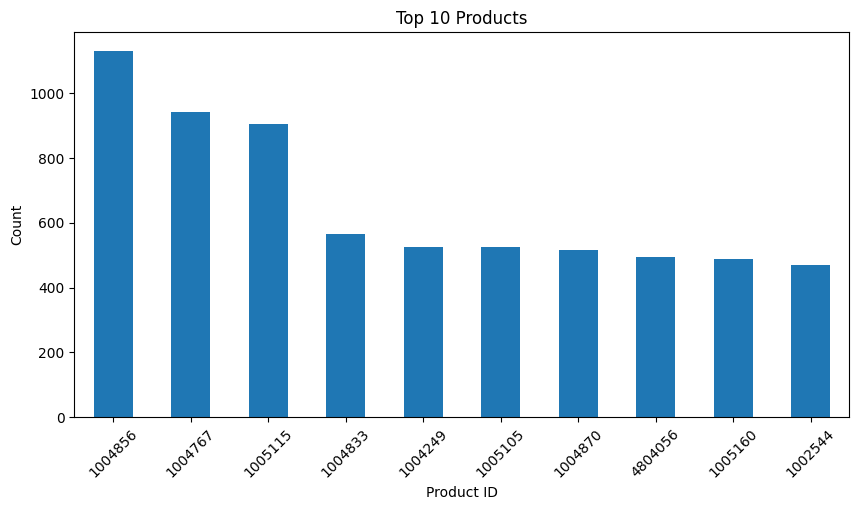

In [46]:
top_product = df["product_id"].value_counts().head(10)

top_product.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products")
plt.xlabel("Product ID")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# 3. User Behavior Funnel Analysis

This section analyzes user conversion from viewing to cart and purchase.

In [47]:
behavior = df["event_type"].value_counts()
behavior

event_type
view        97489
purchase     1422
cart         1089
Name: count, dtype: int64

In [48]:
behavior_rate = behavior / behavior.sum() * 100
behavior_rate

event_type
view        97.489
purchase     1.422
cart         1.089
Name: count, dtype: float64

In [49]:
view_to_cart = cart_count / view_count * 100
cart_to_purchase = purchase_count / cart_count * 100
view_to_purchase = purchase_count / view_count * 100

print(f"View → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"View → Purchase: {view_to_purchase:.2f}%")

NameError: name 'cart_count' is not defined

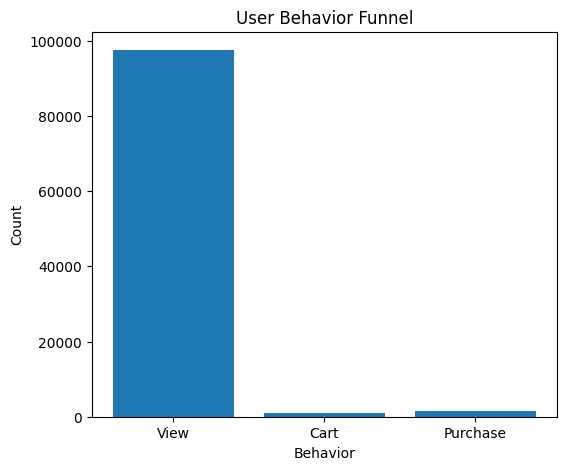

In [ ]:
import matplotlib.pyplot as plt

steps = ["View", "Cart", "Purchase"]
counts = [view_count, cart_count, purchase_count]

plt.figure(figsize=(6,5))
plt.bar(steps, counts)

plt.title("User Behavior Funnel")
plt.xlabel("Behavior")
plt.ylabel("Count")

plt.show()

### Insight

The conversion rate from view to purchase is very low, indicating a large potential for optimization in user conversion.

# 4. Brand Purchase Rate Analysis

This section evaluates brand performance based on purchase conversion rate.

In [ ]:
brand_view = df[df["event_type"] == "view"]["brand"].value_counts()

In [ ]:
brand_purchase = df[df["event_type"] == "purchase"]["brand"].value_counts()

In [ ]:
brand_rate = (
    brand_purchase / brand_view * 100
).sort_values(ascending=False)

brand_rate.head(10)

brand
baldessarini    100.000000
dsquared         50.000000
bethesda         50.000000
yunteng          50.000000
elite            33.333333
roingto          33.333333
ecocool          33.333333
boccia           20.000000
nutrex           20.000000
nutricia         16.666667
Name: count, dtype: float64

In [ ]:
# 只保留浏览次数大于100的品牌
brand_view = brand_view[brand_view >= 100]

brand_rate = (
    brand_purchase / brand_view * 100
).dropna().sort_values(ascending=False)

brand_rate.head(10)

brand
elari        7.317073
ariston      4.444444
kapsen       3.787879
transcend    3.389831
indesit      3.350970
apple        3.093677
nokian       3.092784
gefest       3.053435
samsung      3.020956
midea        2.867384
Name: count, dtype: float64

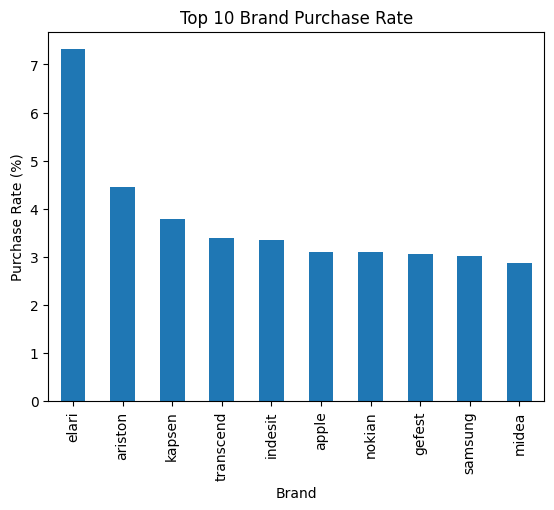

In [ ]:
brand_rate.head(10).plot(kind="bar")

plt.title("Top 10 Brand Purchase Rate")
plt.xlabel("Brand")
plt.ylabel("Purchase Rate (%)")

plt.show()

### Insight

Some niche brands have higher purchase rates than popular brands, indicating stronger conversion efficiency.

# 5. Price Segment Analysis

In [ ]:
bins = [0, 100, 300, 500, 1000, 3000]
labels = ["0-100", "100-300", "300-500", "500-1000", "1000+"]

df["price_range"] = pd.cut(
    df["price"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
view_price = (
    df[df["event_type"] == "view"]["price_range"]
    .value_counts()
    .sort_index()
)

view_price

price_range
0-100       34061
100-300     34848
300-500     13160
500-1000    10870
1000+        4550
Name: count, dtype: int64

In [ ]:
purchase_price = (
    df[df["event_type"] == "purchase"]["price_range"]
    .value_counts()
    .sort_index()
)

purchase_price

price_range
0-100       431
100-300     592
300-500     182
500-1000    162
1000+        55
Name: count, dtype: int64

In [ ]:
price_rate = (
    purchase_price / view_price * 100
).round(2)

price_rate

price_range
0-100       1.27
100-300     1.70
300-500     1.38
500-1000    1.49
1000+       1.21
Name: count, dtype: float64

In [ ]:
top_users = df["user_id"].value_counts().head(10)
top_users

user_id
513002539    140
534949460     99
514127132     97
530337676     93
534838878     87
515129681     86
566301046     86
512483076     85
557212976     83
523673770     82
Name: count, dtype: int64

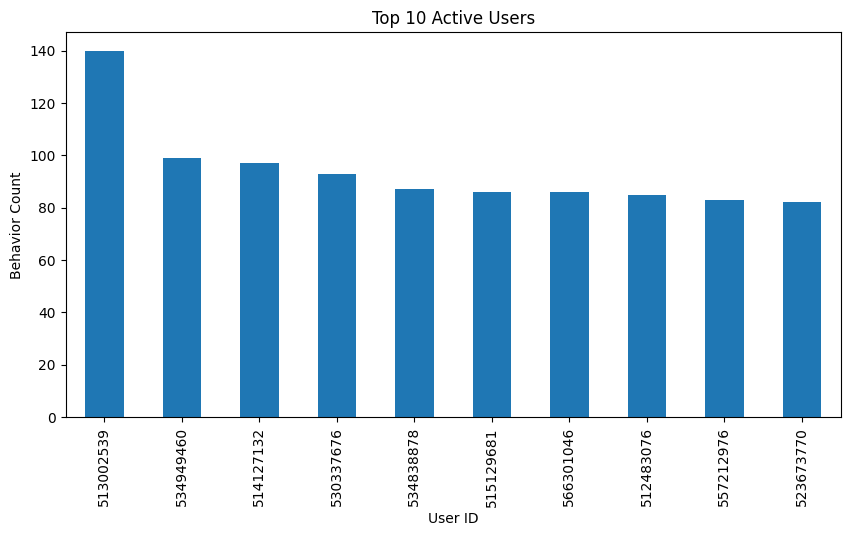

In [ ]:
plt.figure(figsize=(10,5))

top_users.plot(kind="bar")

plt.title("Top 10 Active Users")
plt.xlabel("User ID")
plt.ylabel("Behavior Count")

plt.show()

### Insight

Products in the 100–300 price range have the highest purchase rate, making it the optimal pricing segment.

# 6. RFM Customer Value Analysis

RFM model is used to evaluate customer value based on Recency, Frequency, and Monetary metrics.

In [ ]:
user_behavior = df.groupby("user_id")["event_type"].count()

user_behavior.describe()

count    20778.000000
mean         4.812783
std          6.714682
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        140.000000
Name: event_type, dtype: float64

In [ ]:
purchase_user = (
    df[df["event_type"]=="purchase"]
    ["user_id"]
    .value_counts()
    .head(10)
)

purchase_user

user_id
565645275    11
530337676     9
516426931     7
557746614     7
557760558     7
514074113     6
558698483     6
564678469     6
521793571     5
546076557     4
Name: count, dtype: int64

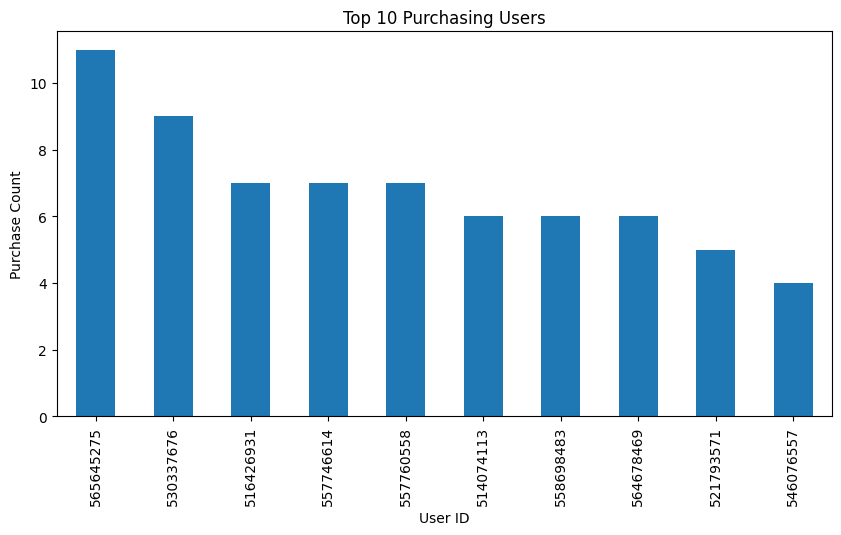

In [ ]:
plt.figure(figsize=(10,5))

purchase_user.plot(kind="bar")

plt.title("Top 10 Purchasing Users")
plt.xlabel("User ID")
plt.ylabel("Purchase Count")

plt.show()

In [ ]:
purchase_df = df[df["event_type"] == "purchase"].copy()

purchase_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,price_range
107,2019-11-01 00:00:41+00:00,purchase,13200605,2053013557192163841,furniture.bedroom.bed,NaN,566.30,559368633,d6034fa2-41fb-4ac0-9051-55ea9fc9147a,0,500-1000
168,2019-11-01 00:01:04+00:00,purchase,1005161,2053013555631882655,electronics.smartphone,xiaomi,211.92,513351129,e6b7ce9b-1938-4e20-976c-8b4163aea11d,0,100-300
707,2019-11-01 00:04:51+00:00,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,128.42,562958505,0f039697-fedc-40fa-8830-39c1a024351d,0,100-300
811,2019-11-01 00:05:34+00:00,purchase,26401669,2053013563651392361,NaN,lucente,109.66,541854711,c41c44d5-ef9b-41b9-9cd6-8d96dda6e927,0,100-300
939,2019-11-01 00:06:33+00:00,purchase,1801881,2053013554415534427,electronics.video.tv,samsung,488.80,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e,0,300-500


In [ ]:
len(purchase_df)

1422

In [ ]:
purchase_df["event_time"].max()

Timestamp('2019-11-01 03:52:43+0000', tz='UTC')

In [ ]:
analysis_date = purchase_df["event_time"].max() + pd.Timedelta(hours=1)

In [ ]:
rfm = purchase_df.groupby("user_id").agg({
    "event_time": lambda x: (
        analysis_date - x.max()
    ).total_seconds() / 3600,
    "user_id": "count",
    "price": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
user_id,,,
356520186,1.055833,1,33.45
486999716,4.306944,1,242.72
512373621,1.678333,1,59.72
512380275,1.451111,1,949.47
512382878,2.128611,1,228.76


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,1159.000000,1159.000000,1159.000000
mean,2.041127,1.226920,346.529422
std,0.892803,0.738364,496.276286
min,1.000000,1.000000,3.840000
25%,1.370417,1.000000,74.260000
50%,1.769167,1.000000,179.410000
75%,2.473056,1.000000,406.685000
max,4.867222,11.000000,5298.120000


In [ ]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

In [ ]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
user_id,,,,,,
356520186,1.055833,1,33.45,5,1,1
486999716,4.306944,1,242.72,1,1,4
512373621,1.678333,1,59.72,3,1,2
512380275,1.451111,1,949.47,4,1,5
512382878,2.128611,1,228.76,2,1,3


In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
user_id,,,,,,,
356520186,1.055833,1,33.45,5,1,1,511
486999716,4.306944,1,242.72,1,1,4,114
512373621,1.678333,1,59.72,3,1,2,312
512380275,1.451111,1,949.47,4,1,5,415
512382878,2.128611,1,228.76,2,1,3,213


In [ ]:
rfm["RFM_Score"].value_counts().head(15)

RFM_Score
555    26
455    26
155    18
321    18
254    17
132    17
211    16
422    16
255    16
142    16
243    16
312    15
511    15
141    15
332    15
Name: count, dtype: int64

In [ ]:
rfm["RFM_Score"].value_counts()

RFM_Score
555    26
455    26
155    18
321    18
254    17
       ..
551     3
134     2
245     2
151     2
351     1
Name: count, Length: 125, dtype: int64

In [ ]:
def customer_segment(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"

    elif F >= 4 and M >= 3:
        return "Loyal"

    elif M >= 4:
        return "Big Spender"

    elif R >= 4:
        return "Potential"

    else:
        return "Others"

In [ ]:
rfm["Segment"] = rfm.apply(customer_segment, axis=1)

In [ ]:
segment_count = rfm["Segment"].value_counts()

segment_count

Segment
Others         381
Potential      230
Big Spender    229
Loyal          219
Champions      100
Name: count, dtype: int64

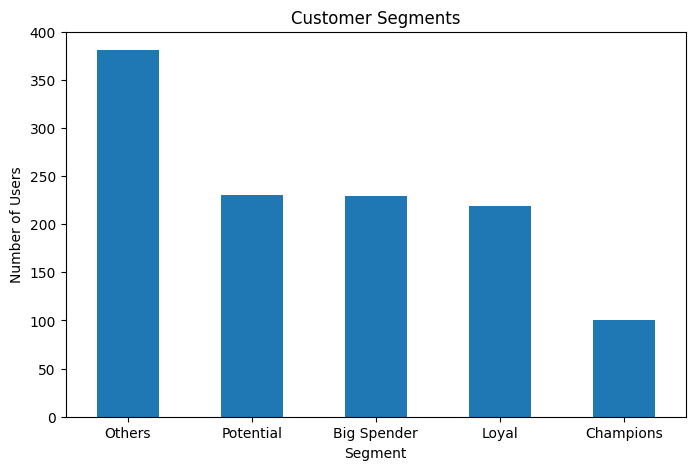

In [ ]:
plt.figure(figsize=(8,5))

segment_count.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Users")

plt.xticks(rotation=0)

plt.show()

### Insight

High-value users exhibit significantly higher frequency and monetary contribution compared to other users.

# 7. Customer Segmentation

In [ ]:
rfm.to_csv("rfm_result.csv", index=True)

In [ ]:
rfm.columns.tolist()

['Recency',
 'Frequency',
 'Monetary',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Score',
 'Segment']

In [ ]:
def segment_user(row):

    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champion"

    elif row["F_Score"] >= 4:
        return "Loyal"

    elif row["M_Score"] >= 4:
        return "Big Spender"

    elif row["R_Score"] >= 4:
        return "Recent"

    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "At Risk"

    else:
        return "Potential"


rfm["Segment"] = rfm.apply(segment_user, axis=1)

In [ ]:
rfm["Segment"].value_counts()

Segment
Loyal          364
Big Spender    229
Recent         178
Potential      171
At Risk        117
Champion       100
Name: count, dtype: int64

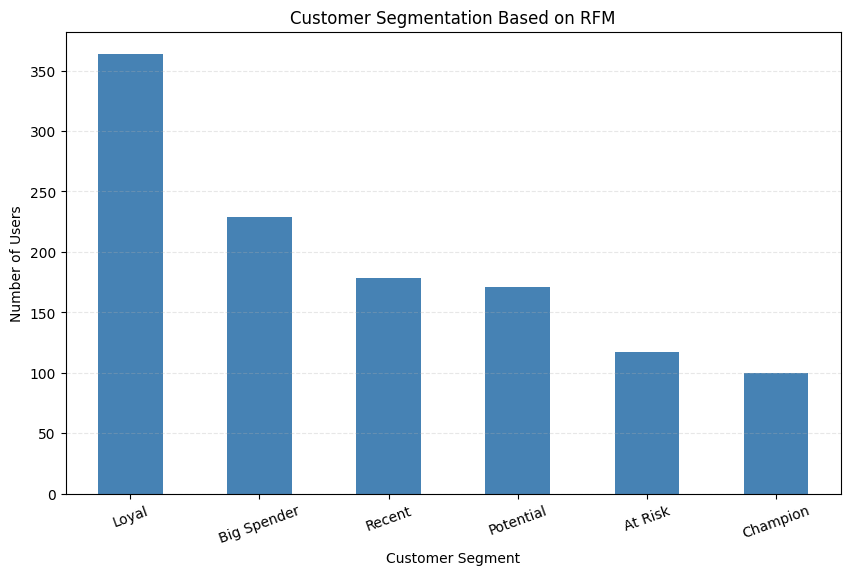

In [ ]:
plt.figure(figsize=(10,6))

rfm["Segment"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Customer Segmentation Based on RFM")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Users")

plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

### Insight

- Champion users are the most valuable group.
- Loyal users contribute stable revenue.
- Big Spenders generate high revenue but low frequency.
- At Risk users require re-engagement strategies.

## Segment Performance Analysis

In [ ]:
segment_summary = rfm.groupby("Segment").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk,2.82,1.00,107.82
Big Spender,2.04,1.00,625.91
Champion,1.29,2.22,907.12
Loyal,2.25,1.39,327.01
Potential,2.27,1.00,102.88
Recent,1.30,1.00,103.06


### Insight

Champion users contribute the highest revenue and purchase frequency, making them the core customer base.

# 8. Business Insights

## Insight 1: Low Conversion Rate Indicates Funnel Inefficiency

Although user browsing volume is high, the conversion rate remains low (~1.46%).

👉 Recommendation:
Improve product detail pages and optimize recommendation system.

## Insight 2: High-Value Customers Drive Revenue

Champion users contribute significantly higher revenue compared to other segments.

👉 Recommendation:
Introduce VIP system and personalized offers.

## Insight 3: Optimal Price Range Identified (100–300)

Products in this price range show the highest conversion rate.

👉 Recommendation:
Focus marketing and inventory in this segment.

## Insight 4: Brand Concentration Effect

A few brands dominate user attention (Samsung, Apple, Xiaomi).

👉 Recommendation:
Allocate more advertising budget to top-performing brands.

## Insight 5: At-Risk Users Require Retention Strategy

A large portion of users show low recent activity.

👉 Recommendation:
Use coupons, push notifications, and remarketing campaigns.

# 9. Conclusion



This project analyzed e-commerce user behavior using 100,000 interaction records.

Key findings:

- User conversion rate is low (~1.46%)
- 100–300 price range performs best
- Champion users contribute highest revenue
- Brand distribution is highly concentrated
- RFM model effectively segments customers

Business recommendations:

- Improve conversion funnel
- Focus on mid-price products
- Retain high-value users
- Re-engage at-risk users